In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [14]:
print("=" * 60)
print("1. LOAD & EXPLORE DATA")
print("=" * 60)

df = pd.read_csv(
    r"C:\Users\USER\Downloads\winequality-red.csv",
    sep=";"
)
print(f"Shape: {df.shape}")
print("\n5 baris pertama:")
print(df.head())

1. LOAD & EXPLORE DATA
Shape: (1599, 12)

5 baris pertama:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0    

In [15]:
# Cek missing values
print("\nMissing values per kolom:")
print(df.isnull().sum())


Missing values per kolom:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [16]:
# Pilih fitur numerik (semua kolom kecuali 'quality')
feature_cols = [col for col in df.columns if col != "quality"]
X = df[feature_cols].copy()

# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
print(f"\nFitur setelah normalisasi ({len(feature_cols)} fitur):")
print(X_scaled.describe().round(3))


Fitur setelah normalisasi (11 fitur):
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count       1599.000          1599.000     1599.000        1599.000   
mean           0.000             0.000       -0.000          -0.000   
std            1.000             1.000        1.000           1.000   
min           -2.137            -2.278       -1.391          -1.163   
25%           -0.701            -0.770       -0.929          -0.453   
50%           -0.241            -0.044       -0.056          -0.240   
75%            0.506             0.627        0.765           0.043   
max            4.355             5.878        3.744           9.196   

       chlorides  free sulfur dioxide  total sulfur dioxide   density  \
count   1599.000             1599.000              1599.000  1599.000   
mean       0.000               -0.000                 0.000    -0.000   
std        1.000                1.000                 1.000     1.000   
min       -1.604             

In [17]:
# 2. TRAINING MODEL

print("\n" + "=" * 60)
print("2. TRAINING ISOLATION FOREST")
print("=" * 60)

model = IsolationForest(
    contamination=0.1,
    random_state=42,
    n_estimators=100
)
model.fit(X_scaled)

df["anomaly"] = model.predict(X_scaled)
# Isolation Forest: -1 = anomaly, 1 = normal
df["anomaly_label"] = df["anomaly"].map({1: "Normal", -1: "Anomali"})

n_anomali = (df["anomaly"] == -1).sum()
n_normal = (df["anomaly"] == 1).sum()
print(f"Normal  : {n_normal} ({100 * n_normal / len(df):.1f}%)")
print(f"Anomali : {n_anomali} ({100 * n_anomali / len(df):.1f}%)")



2. TRAINING ISOLATION FOREST
Normal  : 1440 (90.1%)
Anomali : 159 (9.9%)


In [18]:
# 3. EVALUASI — Statistik per kelompok

print("\n" + "=" * 60)
print("3. EVALUASI — Statistik per Kelompok")
print("=" * 60)

stats = df.groupby("anomaly_label")[feature_cols].describe().round(3)
print(stats)


3. EVALUASI — Statistik per Kelompok
              fixed acidity                                           \
                      count   mean    std  min  25%  50%   75%   max   
anomaly_label                                                          
Anomali               159.0  8.721  2.826  4.6  6.6  8.2  10.3  15.9   
Normal               1440.0  8.275  1.572  5.2  7.1  7.9   9.1  13.4   

              volatile acidity         ... sulphates       alcohol          \
                         count   mean  ...       75%   max   count    mean   
anomaly_label                          ...                                   
Anomali                  159.0  0.550  ...      0.97  2.00   159.0  10.738   
Normal                  1440.0  0.525  ...      0.71  1.56  1440.0  10.388   

                                                  
                 std  min  25%   50%   75%   max  
anomaly_label                                     
Anomali        1.600  8.4  9.4  10.2  12.0  14.9  
Normal


4. VISUALISASI
  -> Grafik 1 disimpan: scatter_bar_comparison.png


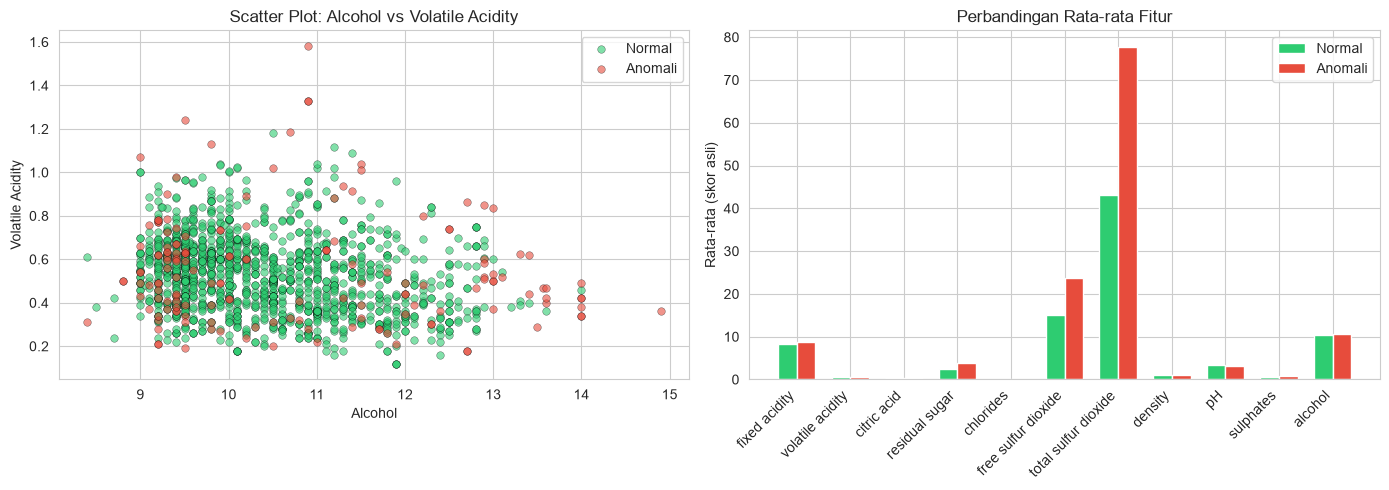

In [21]:
# 4. GRAFIK

print("\n" + "=" * 60)
print("4. VISUALISASI")
print("=" * 60)

sns.set_style("whitegrid")
colors = {"Normal": "#2ecc71", "Anomali": "#e74c3c"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scatter Plot: alcohol vs volatile acidity
ax = axes[0]
for label in ["Normal", "Anomali"]:
    subset = df[df["anomaly_label"] == label]
    ax.scatter(
        subset["alcohol"], subset["volatile acidity"],
        c=colors[label], label=label, alpha=0.6, edgecolors="k", linewidth=0.3, s=30
    )
ax.set_xlabel("Alcohol")
ax.set_ylabel("Volatile Acidity")
ax.set_title("Scatter Plot: Alcohol vs Volatile Acidity")
ax.legend()

# --- Bar Chart: perbandingan rata-rata fitur
ax = axes[1]
mean_normal = df[df["anomaly_label"] == "Normal"][feature_cols].mean()
mean_anomali = df[df["anomaly_label"] == "Anomali"][feature_cols].mean()
x = np.arange(len(feature_cols))
w = 0.35
ax.bar(x - w / 2, mean_normal.values, w, label="Normal", color=colors["Normal"])
ax.bar(x + w / 2, mean_anomali.values, w, label="Anomali", color=colors["Anomali"])
ax.set_xticks(x)
ax.set_xticklabels(feature_cols, rotation=45, ha="right")
ax.set_ylabel("Rata-rata (skor asli)")
ax.set_title("Perbandingan Rata-rata Fitur")
ax.legend()

plt.tight_layout()
plt.savefig("scatter_bar_comparison.png", dpi=150)
print("  -> Grafik 1 disimpan: scatter_bar_comparison.png")


5. PREDIKSI DATA BARU (BUATAN)

Hasil Prediksi Data Baru:
                             skor_anomali    label
Sampel 1 (rendah)               -0.398538   Normal
Sampel 2 (sedang)               -0.460012   Normal
Sampel 3 (tinggi)               -0.776594  Anomali
Sampel 4 (ekstrim)              -0.691571  Anomali
Sampel 5 (normal rata-rata)     -0.413821   Normal


c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


  -> Grafik 2 disimpan: horizontal_bar_prediksi.png

Selesai.


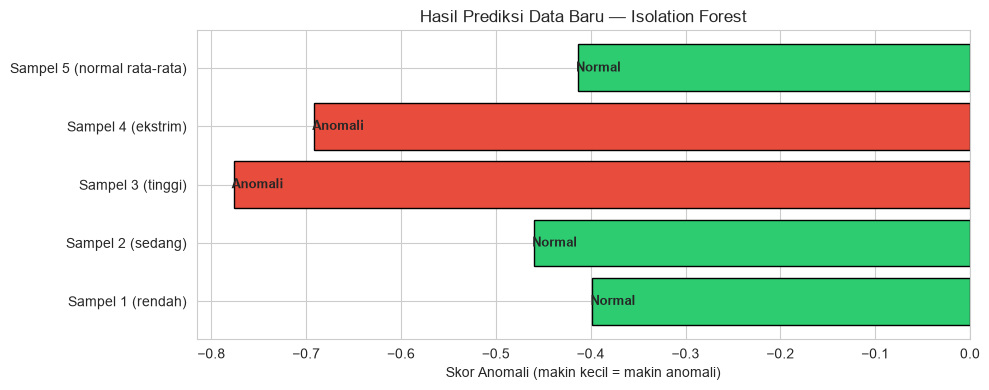

In [20]:
# 5. TESTING DATA BARU
# ============================================================
print("\n" + "=" * 60)
print("5. PREDIKSI DATA BARU (BUATAN)")
print("=" * 60)

data_baru = pd.DataFrame([
    {"fixed acidity": 7.4, "volatile acidity": 0.70, "citric acid": 0.00,
     "residual sugar": 1.9, "chlorides": 0.076, "free sulfur dioxide": 11,
     "total sulfur dioxide": 34, "density": 0.9978, "pH": 3.51,
     "sulphates": 0.56, "alcohol": 9.4},
    {"fixed acidity": 8.5, "volatile acidity": 0.28, "citric acid": 0.56,
     "residual sugar": 1.8, "chlorides": 0.092, "free sulfur dioxide": 35,
     "total sulfur dioxide": 103, "density": 0.9969, "pH": 3.30,
     "sulphates": 0.75, "alcohol": 10.5},
    {"fixed acidity": 4.0, "volatile acidity": 1.50, "citric acid": 0.00,
     "residual sugar": 12.0, "chlorides": 0.500, "free sulfur dioxide": 90,
     "total sulfur dioxide": 300, "density": 1.0020, "pH": 2.80,
     "sulphates": 0.20, "alcohol": 8.0},
    {"fixed acidity": 15.0, "volatile acidity": 0.10, "citric acid": 0.00,
     "residual sugar": 0.5, "chlorides": 0.020, "free sulfur dioxide": 3,
     "total sulfur dioxide": 10, "density": 0.9900, "pH": 4.00,
     "sulphates": 2.00, "alcohol": 14.0},
    {"fixed acidity": 10.0, "volatile acidity": 0.40, "citric acid": 0.30,
     "residual sugar": 3.0, "chlorides": 0.100, "free sulfur dioxide": 25,
     "total sulfur dioxide": 75, "density": 0.9970, "pH": 3.20,
     "sulphates": 0.70, "alcohol": 11.0},
], index=["Sampel 1 (rendah)", "Sampel 2 (sedang)", "Sampel 3 (tinggi)",
          "Sampel 4 (ekstrim)", "Sampel 5 (normal rata-rata)"])

data_baru_scaled = scaler.transform(data_baru[feature_cols])
data_baru["skor_anomali"] = model.score_samples(data_baru_scaled)
data_baru["prediksi"] = model.predict(data_baru_scaled)
data_baru["label"] = data_baru["prediksi"].map({1: "Normal", -1: "Anomali"})

print("\nHasil Prediksi Data Baru:")
print(data_baru[["skor_anomali", "label"]])

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ["#e74c3c" if v == -1 else "#2ecc71" for v in data_baru["prediksi"]]
ax.barh(data_baru.index, data_baru["skor_anomali"], color=bar_colors, edgecolor="k")
ax.axvline(x=0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Skor Anomali (makin kecil = makin anomali)")
ax.set_title("Hasil Prediksi Data Baru — Isolation Forest")
for i, (skor, lbl) in enumerate(zip(data_baru["skor_anomali"], data_baru["label"])):
    ax.text(skor - 0.01, i, f"  {lbl}", va="center", fontweight="bold", fontsize=9)
plt.tight_layout()
plt.savefig("horizontal_bar_prediksi.png", dpi=150)
print("  -> Grafik 2 disimpan: horizontal_bar_prediksi.png")

print("\nSelesai.")